# 3. Rezultati

Šta se ovde pokazuje: koliko je naučena politika dobra na sintetici, prenosi li
se na instance iz literature i na stvaran grad, i šta od zamišljenog nije radilo.

> **Napomena:** tabele u `results/` su računate pre ispravke funkcije cilja
> (`UNSERVED_FACTOR` 4 -> 8, vidi nalaz J). Pregenerisati posle pretreniravanja.

In [1]:
import sys
from pathlib import Path

KOREN = Path.cwd().parent
sys.path.insert(0, str(KOREN))

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

In [2]:
from IPython.display import Markdown, Image

def tabela(ime):
    return Markdown((KOREN / "results" / f"{ime}.md").read_text(encoding="utf-8"))

## 3.1 Held-out sintetika

*(popuniti: šta znači da politika gubi od hill climbinga a dobija od greedyja)*

In [3]:
tabela('main-20-v2')

# Held-out sintetika (20 gradova, n [15, 30], R=4, alpha=0.5, model runs/gravity-v2/best.pt)

`cilj` = alpha * C_p_all/donja_granica + (1-alpha) * C_o/MST; manje je bolje.
Nepokrivena tražnja je već u C_p_all (nepokriven par se naplaćuje 4x uličnim
najkraćim vremenom), pa nema zasebne kazne. `C_p` je prosek samo nad opsluženim
parovima i dat je radi poređenja sa literaturom — između metoda sa različitim
`d_un` nije uporediv, za to služi `C_p_all`.

± je standardna devijacija po gradovima. Δ i p su **uparene** razlike u `cilj`
u odnosu na `greedy` (Wilcoxon, isti gradovi); Δ>0 znači bolje od reference.

| metoda | cilj | Δ vs greedy | p | C_p_all | C_p | C_o | d_0 | d_un | s/grad |
|---|---|---|---|---|---|---|---|---|---|
| random 200 | 1.749 ± 0.121 | -0.221 ± 0.027 | <0.001 | 10.28 | 6.36 | 57 | 0.59 | 0.257 | 0.11 |
| greedy | 1.528 ± 0.107 | — | — | 9.97 | 5.61 | 38 | 0.59 | 0.245 | 0.26 |
| hill climbing | 1.373 ± 0.079 | +0.155 ± 0.017 | <0.001 | 7.54 | 6.08 | 54 | 0.76 | 0.069 | 1.43 |
| RL greedy dekod | 1.611 ± 0.176 | -0.083 ± 0.041 | 0.083 | 9.52 | 6.17 | 54 | 0.76 | 0.139 | 0.08 |
| RL sampling 32 | 1.411 ± 0.084 | +0.117 ± 0.018 | <0.001 | 7.82 | 5.94 | 54 | 0.79 | 0.082 | 2.49 |


## 3.2 Prenos na instance iz literature

Mandl i Mumford se puštaju sa svojim standardnim parametrima, dakle van
distribucije na kojoj je politika trenirana.

*(popuniti: gde prenos radi a gde ne)*

In [4]:
tabela('bench-transfer')

# Transfer na benchmark instance (model runs/gravity-v1/best.pt, alpha=0.5)

Politika je trenirana na sintetici sa n [15, 30], R=4, dužina linije [2, 8].
Instance se puštaju sa svojim standardnim parametrima, dakle van te
distribucije — kolona `van distr.` kaže koliko.

| instanca | n | R | metoda | cilj | C_p_all | C_p | C_o | d_un | s |
|---|---|---|---|---|---|---|---|---|---|
| Mandl1 | 15 | 6 | random 200 | 1.482 | 16.63 | 13.69 | 82 | 0.067 | 0.1 |
| Mandl1 | 15 | 6 | hill climbing | 1.214 | 13.49 | 13.49 | 68 | 0.000 | 1.3 |
| Mandl1 | 15 | 6 | RL greedy dekod | 2.125 | 15.69 | 11.14 | 169 | 0.100 | 0.2 |
| Mandl1 | 15 | 6 | RL sampling 32 | 1.601 | 12.99 | 12.99 | 120 | 0.000 | 4.1 |
| Mandl1 | 15 | 6 | greedy | 1.220 | 13.14 | 13.14 | 71 | 0.000 | 0.2 |
| Mumford0 | 30 | 12 | random 200 | 2.222 | 27.36 | 24.61 | 220 | 0.078 | 0.3 |
| Mumford0 | 30 | 12 | hill climbing | 1.586 | 22.71 | 22.71 | 134 | 0.000 | 3.3 |
| Mumford0 | 30 | 12 | RL greedy dekod | 3.295 | 37.57 | 28.97 | 348 | 0.379 | 0.4 |
| Mumford0 | 30 | 12 | RL sampling 32 | 2.187 | 36.83 | 24.97 | 145 | 0.475 | 6.8 |
| Mumford0 | 30 | 12 | greedy | 1.802 | 33.04 | 22.44 | 100 | 0.363 | 1.6 |
| Mumford1 | 70 | 15 | random 200 | 3.059 | 30.25 | 30.25 | 1037 | 0.000 | 1.1 |
| Mumford1 | 70 | 15 | hill climbing | 2.120 | 31.57 | 31.57 | 593 | 0.000 | 5.9 |
| Mumford1 | 70 | 15 | RL greedy dekod | 3.067 | 55.15 | 41.68 | 746 | 0.375 | 0.8 |
| Mumford1 | 70 | 15 | RL sampling 32 | 2.571 | 43.07 | 33.41 | 663 | 0.216 | 22.1 |
| Mumford2 | 110 | 56 | random 200 | 5.782 | 32.71 | 32.71 | 3571 | 0.000 | 4.1 |
| Mumford2 | 110 | 56 | hill climbing | 3.659 | 31.33 | 31.33 | 2090 | 0.000 | 49.9 |
| Mumford2 | 110 | 56 | RL greedy dekod | 7.289 | 76.19 | 44.73 | 3944 | 0.667 | 5.1 |
| Mumford2 | 110 | 56 | RL sampling 32 | 4.425 | 48.64 | 37.07 | 2356 | 0.205 | 87.5 |
| Mumford3 | 127 | 60 | random 200 | 6.284 | 34.76 | 34.76 | 4398 | 0.000 | 5.7 |
| Mumford3 | 127 | 60 | hill climbing | 4.081 | 37.11 | 37.11 | 2625 | 0.000 | 38.7 |
| Mumford3 | 127 | 60 | RL greedy dekod | 7.133 | 85.97 | 80.53 | 4252 | 0.424 | 6.1 |
| Mumford3 | 127 | 60 | RL sampling 32 | 4.736 | 44.32 | 39.36 | 3026 | 0.102 | 126.4 |


## 3.3 Ablacije i varijansa po seedu

*(popuniti: zašto se ablacije čitaju tek uz seed varijansu)*

In [5]:
tabela('ablacije')

# Ablacije i varijansa po seed-u

Sve na istih 20 held-out sintetičkih gradova, `n [15, 30]`, `R=4`, `alpha=0.5`.
Referentne vrednosti baselina su iste u svim redovima jer ne zavise od modela:
`random 200` 1.749, **`greedy` 1.528**, `hill climbing` 1.373.

Δ i p su uparene razlike u `cilj` u odnosu na `greedy` (Wilcoxon, isti gradovi);
Δ>0 znači bolje od greedyja.

## Varijansa po seed-u

Isti config, tri seed-a treninga. Ovo se čita pre ablacija, jer postavlja meru
za to koliko razlika uopšte znači nešto.

| seed | RL greedy dekod | RL sampling 32 | Δ vs greedy | p |
|---|---|---|---|---|
| 0 (`gravity-v1`) | 1.715 ± 0.196 | 1.547 ± 0.088 | -0.019 ± 0.019 | 0.114 |
| 1 | 1.777 ± 0.130 | 1.606 ± 0.122 | -0.078 ± 0.020 | <0.001 |
| 2 | 1.785 ± 0.202 | 1.563 ± 0.091 | -0.035 ± 0.017 | 0.048 |
| **prosek po seed-u** | **1.759 ± 0.038** | **1.572 ± 0.031** | | |

**Politika gubi od greedyja na sva tri seed-a.** Seed 0 je najpovoljniji od tri i
jedini na kom razlika nije statistički značajna; to je ujedno seed koji stoji u
`main-20-v1.md`. Rasipanje po seed-u (±0.031) je istog reda kao razlika između modela
i greedyja (0.044), pa se svaka ablacija mora čitati sa tom merom u ruci.

## Ablacije

Jedan trening po redu, sve sa seed-om 0.

| varijanta | RL greedy dekod | RL sampling 32 | Δ vs greedy | p |
|---|---|---|---|---|
| osnovna (`gravity-v1`) | 1.715 ± 0.196 | 1.547 ± 0.088 | -0.019 ± 0.019 | 0.114 |
| fiksni `alpha=0.5` | 1.614 ± 0.125 | 1.504 ± 0.124 | +0.024 ± 0.024 | 0.245 |
| self-critical baseline | 1.712 ± 0.154 | 1.582 ± 0.104 | -0.054 ± 0.017 | 0.006 |
| bez standardizacije advantage-a | 1.762 ± 0.281 | 1.578 ± 0.117 | -0.050 ± 0.022 | 0.048 |

Šta se iz ovoga vidi:

- **Fiksni `alpha` je bolji od uzorkovanog** (1.504 vs 1.547), i to za više nego što
  iznosi rasipanje po seed-u. Uzorkovanje `alpha ~ U[0,1]` nije besplatno: jedna
  politika pokriva ceo Pareto front (`pareto.md`), ali je na `alpha=0.5` slabija od
  politike koja samo tu vrednost i vidi. To je trošak, ne poboljšanje, i tako treba
  da stoji u radu.

  Praktična posledica: **`abl-alpha-fixed` na `alpha=0.5` tuče greedy** (1.504 naspram
  1.528), dok ga `gravity-v1` ne tuče. Dva modela pripadaju različitim tabelama —
  fiksni-alpha model tamo gde se izveštava jedna vrednost alpha, uslovljeni model tamo
  gde se crta ceo front. Trenutno `main-20-v1.md` koristi uslovljeni model, što je za tu
  tabelu pogrešan izbor.
- **Naučeni baseline je bolji od self-critical** (1.547 vs 1.582), suprotno od Kool
  et al. gde je self-critical jači. Razlika je mala i u opsegu seed varijanse.
- **Standardizacija advantage-a pomaže**, ali takođe unutar seed varijanse
  (1.547 vs 1.578). Bez nje je dekodiranje greedyjem osetno nestabilnije (±0.281).

Nijedna od ove tri razlike nije dovoljno velika da bi se na njoj gradio zaključak
sa tri seed-a po varijanti. U radu idu kao tabela sa napomenom o varijansi, ne kao
tvrdnje o tome šta „radi bolje".

## Featuri iz analize kompleksnih mreža

Hipoteza: tri GATv2 sloja imaju receptivno polje od tri skoka, pa globalne mere
treba dati spolja jer ih mreža ne može izvesti. `abl-akm` menja sva četiri
dodatka odjednom; ostala četiri reda menjaju po jedan, da se vidi ko nosi efekat.

| dodatak | RL greedy dekod | RL sampling 32 | Δ vs greedy | p |
|---|---|---|---|---|
| osnovna (`gravity-v1`) | 1.715 ± 0.196 | 1.547 ± 0.088 | -0.019 ± 0.019 | 0.114 |
| betweenness | 1.786 ± 0.237 | 1.551 ± 0.099 | -0.023 ± 0.021 | 0.202 |
| sva četiri (`abl-akm`) | 1.758 ± 0.185 | 1.553 ± 0.111 | -0.025 ± 0.018 | 0.231 |
| coreness | 1.799 ± 0.231 | 1.563 ± 0.117 | -0.035 ± 0.020 | 0.189 |
| rang za stepen čvora | 1.720 ± 0.163 | 1.568 ± 0.105 | -0.040 ± 0.016 | 0.033 |
| closeness | 1.771 ± 0.229 | 1.572 ± 0.122 | -0.044 ± 0.022 | 0.044 |

**Hipoteza nije potvrđena.** Svih pet varijanti pada u pojas seed varijanse
osnovne konfiguracije (1.547–1.606), i sve su nominalno lošije od nje. Poredak u
tabeli je poredak šuma, ne efekta.

Provera na svom terenu je takođe negativna. Ako je uzrok receptivno polje, efekat
bi se video na instancama čiji prečnik daleko prelazi tri skoka:

| instanca | n | osnovna | betweenness |
|---|---|---|---|
| Mumford2 | 110 | **4.425** | 4.710 |
| Mumford3 | 127 | **4.736** | 5.028 |

Betweenness je gori i tamo. Poređenje je pouzdano jer se `random 200` i
`hill climbing` reprodukuju do treće decimale. Uz to, greedy dekodiranje
betweenness modela na Mumford2 vraća nevalidnu mrežu sa dupliranim linijama.

Objašnjenje koje najbolje pristaje brojevima: rang-transformisan betweenness je
jak signal koji politiku vuče u iste centralne čvorove. Na Mumford2 to snižava
`C_p_all` (48.64 → 42.11) ali podiže `C_o` (2356 → 2662) — linije postaju bolje
za putnika pojedinačno a međusobno redundantne. Centralnost je dobra mera za
analizu mreže i loš induktivni bias za njeno projektovanje, jer projektovanje
traži da se linije razmaknu, a centralnost ih skuplja.

Metodološka ograda vredi ponoviti: sa tri seeda osnovne konfiguracije koji se
razlikuju 0.059 u `cilj`, jedan seed po ablaciji ne razlučuje efekte ove veličine.
Dva merenja na `abl-betweenness` daju suprotan znak — `val_score` unutar treninga
je 1.099, najviši od svih runova sa 3000 iteracija, a `cilj` na held-out gradovima
je 1.551, unutar pojasa. Ta nesaglasnost je i sama podatak o tome koliko jedan
seed vredi.

## Gravity vs uniform tražnja

`abl_uniform` se **ne upisuje u gornju tabelu** jer se ne poredi sa istim brojevima:
politika trenirana na uniform tražnji se i evaluira na uniform held-out gradovima,
pa su i baselines tamo drugačiji (`greedy` 1.825, `hill climbing` 1.546,
`random 200` 1.888).

| režim | greedy | hill climbing | RL sampling 32 | Δ vs greedy | p |
|---|---|---|---|---|---|
| gravity | 1.528 | 1.373 | 1.547 | -0.019 ± 0.019 | 0.114 |
| uniform | 1.825 | 1.546 | 1.850 | -0.026 ± 0.052 | 0.648 |

Odnos prema baselinima je u oba režima isti — politika sustiže greedy i gubi od
lokalne pretrage. Uniform instance su same po sebi teže za sve metode (`d_un` kod
greedyja 0.577 naspram 0.245 na gravity instancama), jer ravnomerna tražnja nema
strukturu koju bi konstruktivna heuristika mogla da iskoristi.

---

Sirovi izlazi po varijanti su u `abl-*.md` i `seed-*.md`; sažeti su ovde jer
odvojene tabele sa identičnim redovima baselina daju više šuma nego signala.
Modeli su u `runs/`, pa se svaka pojedinačna tabela vraća sa:

```bash
python -m tndp.experiments.bench_synth runs/abl-alpha-fixed/best.pt --out abl_alpha_fixed
```


## 3.4 Novi Sad

*(popuniti: šta poređenje sa GSP mrežom kaže a šta ne)*

In [6]:
tabela('novisad-poredjenje')

# Novi Sad: model naspram postojeće GSP mreže

Politika je trenirana na SINTETIČKIM gradovima (n [28, 36], R=19, dužina linije [4, 20])
i puštena na Novi Sad u jednom prolazu, bez dotreniravanja. To je tvrdnja
koju rad proverava.

Instanca: n=32 zona, R=19 linija, dužina [2, 14], alpha=0.5.
Model: `runs/novisad-r19/best.pt`.

`cilj` je isti skalar za sve metode, manje je bolje. `Jaccard` meri
poklapanje sa GSP mrežom po parovima uzastopnih zona , koliko model
gradi iste koridore kao stvarni planeri.

| metoda | cilj | vs GSP | C_p_all | C_p | C_o | d_0 | d_un | Jaccard | s |
|---|---|---|---|---|---|---|---|---|---|
| GSP (postojeća) | 3.313 | , | 16.45 | 16.45 | 301.9 | 0.33 | 0.000 | 1.000 | 0.0 |
| random 200 | 3.142 | +0.171 | 16.13 | 16.13 | 282.6 | 0.28 | 0.000 | 0.549 | 0.4 |
| greedy | 1.681 | +1.632 | 16.27 | 16.27 | 99.2 | 0.18 | 0.000 | 0.452 | 4.4 |
| hill climbing | 1.648 | +1.665 | 16.21 | 16.21 | 95.6 | 0.20 | 0.000 | 0.435 | 6.5 |
| RL greedy dekod | 6.893 | -3.580 | 47.16 | 25.82 | 540.1 | 0.53 | 0.443 | 0.115 | 0.7 |
| RL sampling 32 | 2.791 | +0.523 | 35.34 | 32.45 | 108.0 | 0.05 | 0.074 | 0.219 | 8.3 |

`vs GSP` je razlika u cilju prema postojećoj mreži; pozitivno znači
bolje od GSP-a po ovom cilju. Treba ga čitati uz ograničenja niže.

## Šta ovo poređenje NE kaže

GSP mreža nije projektovana po ovom cilju, pa je porediti po njemu je
delom nepravedno u oba smera:

- cilj ne vidi frekvencije, kapacitet ni vozni park, a GSP linije postoje
  u režimu u kom te stvari odlučuju (vidi results/novisad-frekvencije.md)
- GSP trase su prevedene u zonski graf, pri čemu su svedene na proste
  puteve i popunjene po susedstvu (results koje daje tndp/novisad/instanca.py);
  to je aproksimacija stvarne trase
- mreža koja postoji nosi i ograničenja koja model ne zna: infrastrukturu,
  okretnice, kolektivne ugovore, istorijske odluke

Zato je `Jaccard` uz `cilj` bitniji nego sam `cilj`: on kaže da li model
prepoznaje iste koridore, što je tvrdnja koja ne zavisi od toga da li je
naša funkcija cilja ista kao ona koju je GSP imao na umu.



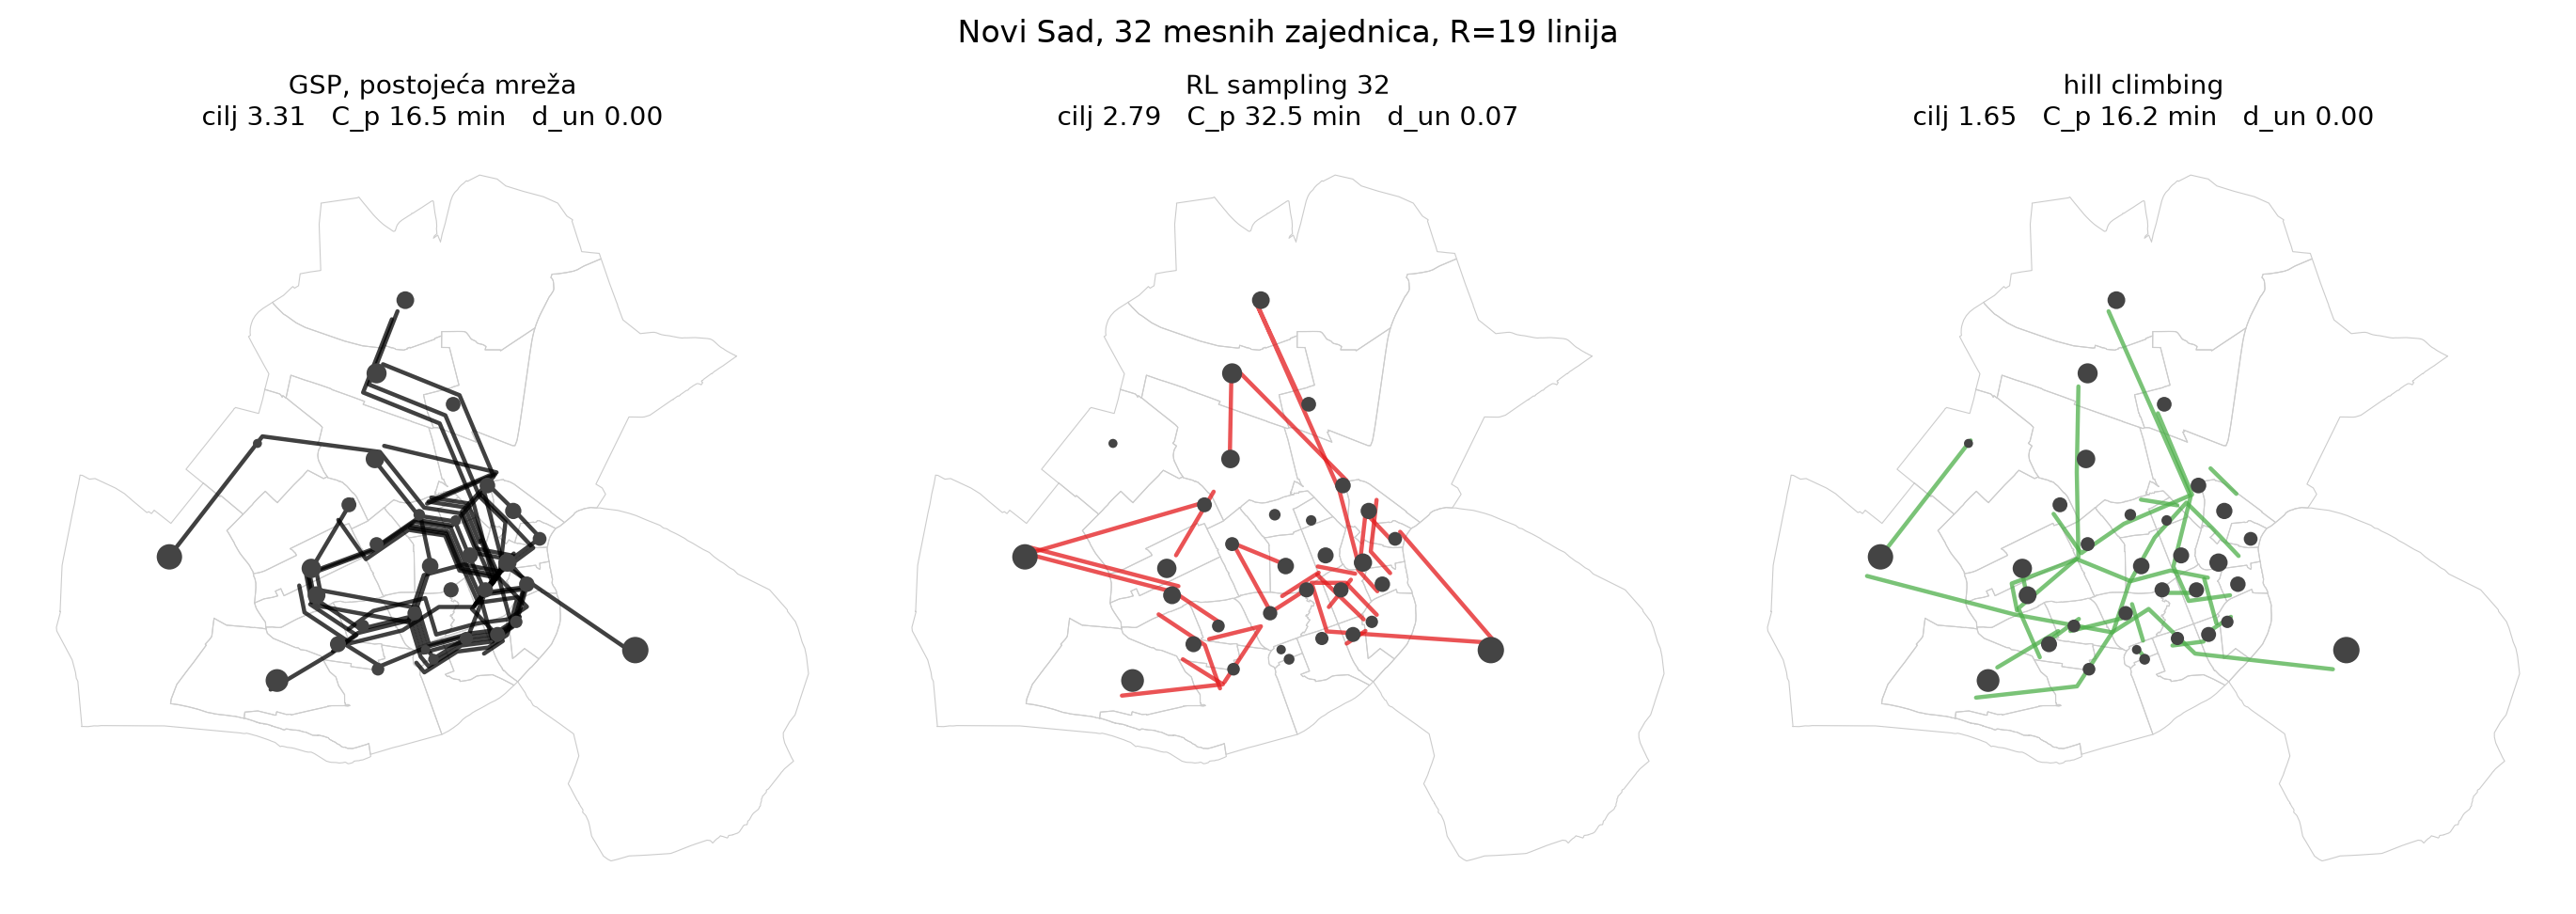

In [7]:
Image(str(KOREN / 'results' / 'novisad-mreze.png'))

## 3.5 Frekvencije

Model dimenzioniše intervale iz opterećenja, bez ijednog podatka o redu vožnje,
pa se poredi sa onim što GSP stvarno vozi.

*(popuniti: zašto je poredak upotrebljiv a pojedinačni intervali nisu)*

In [8]:
tabela('novisad-frekvencije')

# Frekvencije: model naspram stvarnog reda vožnje

Frekvencijska faza (`core/frequencies.oceni`) dimenzioniše intervale iz
opterećenja najopterećenije deonice. Do sad je puštana samo na Mandlu i
Mumfordu, gde nema reda vožnje pa nema ni provere. Ovde se pušta na
**postojeću GSP mrežu Novog Sada**, čiji je red vožnje poznat.

Stvarni interval je broj polazaka u vršnom satu (13:00-14:00,
radni dan, smer A). Model ne dobija nijedan podatak o redu vožnje ,
izvodi intervale samo iz tražnje, trasa i kapaciteta vozila.

| linija | red vožnje | model | razlika | vozila |
|---|---|---|---|---|
| 7 | 7.5 min | 60.0 min | +52.5 min | 1 |
| 11 | 8.6 min | 5.0 min | -3.6 min | 10 |
| 3 | 10.0 min | 9.8 min | -0.2 min | 4 |
| 8 | 10.0 min | 5.0 min | -5.0 min | 9 |
| 1 | 12.0 min | 5.7 min | -6.3 min | 8 |
| 5 | 12.0 min | 60.0 min | +48.0 min | 1 |
| 9 | 12.0 min | 5.0 min | -7.0 min | 11 |
| 2 | 15.0 min | 5.0 min | -10.0 min | 6 |
| 4 | 15.0 min | 60.0 min | +45.0 min | 1 |
| 6 | 15.0 min | 5.0 min | -10.0 min | 10 |
| 12 | 15.0 min | 15.7 min | +0.7 min | 3 |
| 10 | 20.0 min | 60.0 min | +40.0 min | 1 |
| 13 | 20.0 min | 60.0 min | +40.0 min | 1 |
| 14 | 20.0 min | 5.0 min | -15.0 min | 11 |
| 15 | 20.0 min | 5.0 min | -15.0 min | 7 |
| 16 | 60.0 min | 60.0 min | +0.0 min | 1 |
| 17 | 60.0 min | 60.0 min | +0.0 min | 1 |
| 18 | 60.0 min | 60.0 min | +0.0 min | 1 |
| 19 | 60.0 min | 60.0 min | +0.0 min | 1 |

## Poklapanje

| mera | vrednost |
|---|---|
| medijana |greška| | +7.000 |
| prosečna greška | +8.108 |
| Pearson | +0.552 |
| Spearman | +0.401 |
| unutar 5 min | +0.421 |

Model traži **88 vozila** za celu mrežu, uz prosečno čekanje 2.7 min.

## Osetljivost na pretpostavke

Kapacitet vozila i udeo vršnog sata su pretpostavke, ne merenja, pa se
poklapanje meri i van podrazumevanih vrednosti.

| konstanta | vrednost | medijana \|greška\| | Spearman |
|---|---|---|---|
| kapacitet | 60 | 9.3 min | +0.411 |
| kapacitet | 80 | 7.0 min | +0.401 |
| kapacitet | 100 | 7.0 min | +0.355 |
| kapacitet | 120 | 8.5 min | +0.336 |
| udeo vrha | 0.08 | 7.0 min | +0.355 |
| udeo vrha | 0.1 | 7.0 min | +0.401 |
| udeo vrha | 0.12 | 8.7 min | +0.411 |

Poklapanje se jedva menja sa tim konstantama, i to je samo po sebi
dijagnoza: većina linija je prikovana za donju ili gornju granicu
intervala, pa ih pomeranje kapaciteta nema gde da pomeri.

## Gde model greši i zašto

Greška nije ravnomerna nego **dvopolna**: linija je ili na podu od 5 min
ili na plafonu od 60. Uzrok je što linija koja ostane bez putnika dobija
najređi dozvoljen interval.

| režim | linija bez ijednog putnika |
|---|---|
| prvi prolaz, fiksni penal | 2 od 19 |
| posle konvergencije petlje | 9 od 19 |
| sa stvarnim redom vožnje | 6 od 19 |

Čitanje: dodela najkraćim putem sama po sebi isprazni šest linija , među
paralelnim linijama u istom koridoru pobednik uzima sve. Petlja koja
izvodi intervale iz opterećenja to pogorša na devet, jer linija sa malim
opterećenjem dobije dug interval, time postane još manje privlačna, i
opterećenje joj padne na nulu. Povratna sprega nije prigušena ničim.

Probano i **ne pomaže**: geometrijsko prigušenje koraka (0.5 i 0.3) i
politički plafon intervala od 30 min umesto 60. Prigušenje pogorša
Spearman na +0.33, plafon podigne medijanu greške na 10 min, a broj praznih
linija u oba slučaja ostaje devet. Dakle kvar nije u petlji nego ispod nje.

Stvarni prevoznik nema ovaj problem iz dva razloga koje model nema:
putnik ulazi u prvu liniju koja naiđe pa se opterećenje deli po
frekvencijama (Spiess-Florian, strategija umesto puta), a nivo usluge je
delom politička odluka , GSP vozi liniju 7 na 7,5 minuta jer je tako
odlučeno, a ne zato što je tražnja to iznudila. Model je predviđa na 60.

**Posledica za rad:** poredak linija po opterećenju je upotrebljiv
(Spearman +0.401), pojedinačni intervali nisu. Svaki
zaključak koji traži tačan interval po liniji , a tu spada i poređenje
vidova prevoza sa tramvajem , mora sačekati dodelu po strategiji.



## 3.6 Šta nije radilo

Pet stvari je provereno i nije se potvrdilo. Svaka je izmerena i ima objašnjenje.

| nalaz | gde |
|---|---|
| featuri iz analize kompleksnih mreža ne pomažu | `results/ablacije.md` |
| MCTS dekoder ne tuče sampling | `results/bench-decoders.md` |
| frekvencijska faza se raspada na paralelnim linijama | `results/novisad-frekvencije.md` |
| beta se ne da kalibrisati, prag može | `results/novisad-kalibracija.md` |
| cilj je preferirao mrežu koja opslužuje 28% grada | `docs/metodoloska-procena.md`, nalaz J |

*(popuniti: zašto negativan nalaz sa mehanizmom vredi više od tvrdnje bez provere)*

## Zaključci

*(popuniti)*